In [ ]:
# Anchor the notebook to the repository root.
#
# Every path below (`data/`, `embeddings/`, the `.pth` weights and the
# `image_path` column stored in the CSVs) is relative to the repository root,
# not to this file. Walking up to the directory that holds `pyproject.toml`
# lets the notebook run from anywhere: `jupyter lab` at the root, from
# `notebooks/`, or from an IDE with its own working directory.
import os
from pathlib import Path

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    adjusted_rand_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from pathlib import Path

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cuda


In [20]:
DATA_DIR = Path(".")

train_df = pd.read_csv(DATA_DIR / "pseudo_labels_gmm.csv")
test_df = pd.read_csv(DATA_DIR / "true_labels_test.csv")

# Verify no overlap between pseudo-labeled and true-labeled images
overlap = set(train_df["image_path"]) & set(test_df["image_path"])
assert (
    len(overlap) == 0
), f"Data leakage : {len(overlap)} images en commun entre train et test"
print("✓ Aucun chevauchement entre train_df et test_df")

print(f"\nTrain (pseudo-labels) : {len(train_df)} images")
print(f"  cancer (1) : {(train_df['label'] == 1).sum()}")
print(f"  normal (0) : {(train_df['label'] == 0).sum()}\n")

print(f"Test  (vrais labels)  : {len(test_df)} images")
print(f"  cancer (1) : {(test_df['label'] == 1).sum()}")
print(f"  normal (0) : {(test_df['label'] == 0).sum()}")

train_df

✓ Aucun chevauchement entre train_df et test_df

Train (pseudo-labels) : 1406 images
  cancer (1) : 787
  normal (0) : 619

Test  (vrais labels)  : 100 images
  cancer (1) : 50
  normal (0) : 50


,image_path,label,proba_cancer,proba_normal
0,data\sans_label\001b158a-7af8-451e-bf31-3a9116...,1,1.0,0.0
1,data\sans_label\00366e8d-5520-4d3c-a70b-91a7ee...,0,0.0,1.0
2,data\sans_label\00455a62-f79f-4072-9a23-4951e7...,0,0.0,1.0
3,data\sans_label\004ce5f5-ca6b-490f-9b2f-c322c1...,1,1.0,0.0
4,data\sans_label\005d9a37-8894-4eb5-8367-1015d4...,1,1.0,0.0
...,...,...,...,...
1401,data\sans_label\ff3d5248-a7a7-47f6-8fe4-a44a45...,1,1.0,0.0
1402,data\sans_label\ff93375a-a8ea-4c44-9679-8b62ff...,0,0.0,1.0
1403,data\sans_label\ffab85a5-cdb8-4c32-aa75-926199...,0,0.0,1.0
1404,data\sans_label\ffae953a-1429-4a56-a258-7c4c01...,1,1.0,0.0


# Split du test set (70/30) --> 50/50

In [21]:
from sklearn.model_selection import train_test_split

# 80/20 stratified split on the labeled test set (50 cancer / 50 normal)
labeled_test_df, labeled_val_df = train_test_split(
    test_df,
    test_size=0.3,
    stratify=test_df["label"],
    random_state=42,
)

print(
    f"Labeled test : {len(labeled_test_df)} images  "
    f"(cancer={( labeled_test_df['label']==1).sum()}, "
    f"normal={(labeled_test_df['label']==0).sum()})"
)
print(
    f"Labeled val   : {len(labeled_val_df)} images  "
    f"(cancer={(labeled_val_df['label']==1).sum()}, "
    f"normal={(labeled_val_df['label']==0).sum()})"
)

Labeled test : 70 images  (cancer=35, normal=35)
Labeled val   : 30 images  (cancer=15, normal=15)


# Fonctions

In [22]:
def evaluate(y_true, y_pred, title="Évaluation"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    ari = adjusted_rand_score(y_true, y_pred)

    print(f"{'─'*40}")
    print(f"  {title}")
    print(f"{'─'*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  F2-score  : {f2:.4f}")
    print(f"  ARI       : {ari:.4f}")
    print(f"{'─'*40}\n")

    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=["Normal (0)", "Cancer (1)"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "f2": f2,
        "ari": ari,
    }


print("Fonction evaluate() prête.")

Fonction evaluate() prête.


In [23]:
import cv2


class GradCAM:
    """Grad-CAM with forward/backward hooks on a target layer.

    Use as a context manager to guarantee hook cleanup:
        with GradCAM(model, layer) as gc:
            cam = gc(tensor, class_idx)
    """

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, "activations", out.detach())
        )
        self._bwd_handle = target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach())
        )

    def __enter__(self):
        return self

    def __exit__(self, *args):
        self.remove()

    def remove(self):
        self._fwd_handle.remove()
        self._bwd_handle.remove()

    def __call__(self, img_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(img_tensor)
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = torch.relu(cam)
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()
        return cam.cpu().numpy()


def overlay_gradcam(img_path, cam, alpha=0.5):
    img = np.array(Image.open(img_path).convert("RGB").resize((224, 224)))
    heatmap = cv2.resize(cam, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    blended = (alpha * heatmap_rgb + (1 - alpha) * img).astype(np.uint8)
    return img, blended


def plot_gradcam_errors(df, y_true, y_pred, gradcam_instance, error_type="FN"):
    """3-column Grad-CAM display for misclassified images.

    Col 0 — original image
    Col 1 — Grad-CAM for the PREDICTED class : "why did the model say X?"
    Col 2 — Grad-CAM for the TRUE class      : "does the model see the real features?"
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if error_type == "FN":
        indices = np.where((y_true == 1) & (y_pred == 0))[0]
        title_prefix = "FN — Cancer manqué"
        pred_class, true_class = 0, 1
        col1_label = "Grad-CAM classe prédite (normal)"
        col2_label = "Grad-CAM classe réelle (cancer)"
    else:
        indices = np.where((y_true == 0) & (y_pred == 1))[0]
        title_prefix = "FP — Fausse alarme"
        pred_class, true_class = 1, 0
        col1_label = "Grad-CAM classe prédite (cancer)"
        col2_label = "Grad-CAM classe réelle (normal)"

    if len(indices) == 0:
        print(f"Aucune erreur de type {error_type}.")
        return

    n_rows = len(indices)
    fig, axes = plt.subplots(n_rows, 3, figsize=(10, n_rows * 3.2))
    if n_rows == 1:
        axes = [axes]

    fig.suptitle(
        f"{title_prefix} — Grad-CAM",
        fontsize=13, fontweight="bold", color="#e74c3c", y=1.0,
    )
    fig.subplots_adjust(top=0.88)

    gradcam_instance.model.eval()
    for row, idx in enumerate(indices):
        img_path = df.iloc[idx]["image_path"]
        img_tensor = TRANSFORMS(Image.open(img_path).convert("RGB"))
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        cam_pred = gradcam_instance(img_tensor.requires_grad_(True), pred_class)
        original, overlay_pred = overlay_gradcam(img_path, cam_pred)

        # Fresh tensor to avoid gradient accumulation between the two passes
        cam_true = gradcam_instance(img_tensor.detach().requires_grad_(True), true_class)
        _, overlay_true = overlay_gradcam(img_path, cam_true)

        axes[row][0].imshow(original)
        axes[row][0].set_title("Image originale", fontsize=9)
        axes[row][0].axis("off")

        axes[row][1].imshow(overlay_pred)
        axes[row][1].set_title(col1_label, fontsize=9)
        axes[row][1].axis("off")

        axes[row][2].imshow(overlay_true)
        axes[row][2].set_title(col2_label, fontsize=9)
        axes[row][2].axis("off")

    plt.tight_layout()
    plt.show()


def run_gradcam_analysis(model, df, y_true, y_pred, phase=""):
    """Run FN + FP Grad-CAM analysis on the last conv layer of model.features."""
    prefix = f" — {phase}" if phase else ""
    with GradCAM(model, model.features[-4]) as gc:
        print(f"Grad-CAM{prefix} — FN (cancers manqués) :")
        plot_gradcam_errors(df, y_true, y_pred, gc, error_type="FN")
        print(f"Grad-CAM{prefix} — FP (fausses alarmes) :")
        plot_gradcam_errors(df, y_true, y_pred, gc, error_type="FP")


print("Fonctions Grad-CAM prêtes.")

Fonctions Grad-CAM prêtes.


# Création datasets, dataloaders, CNN

In [24]:
# Inference transforms — no augmentation, just resize + normalize to [0,1]
TRANSFORMS = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class MRIset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        with Image.open(self.df.iloc[idx]["image_path"]) as img:
            if self.transform:
                img = self.transform(img)
        label = self.df.iloc[idx]["label"]
        return img, label


dataset_weak = MRIset(train_df, transform=TRANSFORMS)
dataset_val = MRIset(labeled_val_df, transform=TRANSFORMS)

loader_weak = DataLoader(
    dataset_weak, batch_size=127, shuffle=True, pin_memory=True, drop_last=True
)
loader_val = DataLoader(dataset_val, batch_size=10, shuffle=False, pin_memory=True)

In [25]:
class MyCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()

        self.features = nn.Sequential(
            # 224 → 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # 112 → 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # 56 → 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # 28 → 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            # 14 → 7
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global Average Pooling
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Phase 1 Clustering + CNN sur labels faibles

In [26]:
model = MyCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 8

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for imgs, labels in loader_weak:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, labels in loader_val:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_loss += criterion(out, labels).item()
    print(
        f"Epoch {epoch+1}: train_loss={running_loss/len(loader_weak):.4f}, val_loss={val_loss/len(loader_val):.4f}"
    )

Epoch 1: train_loss=0.5771, val_loss=1.3325
Epoch 2: train_loss=0.3623, val_loss=2.1980
Epoch 3: train_loss=0.2993, val_loss=1.3175
Epoch 4: train_loss=0.2654, val_loss=0.8446
Epoch 5: train_loss=0.2809, val_loss=0.7161
Epoch 6: train_loss=0.2565, val_loss=1.0030
Epoch 7: train_loss=0.2237, val_loss=0.7803
Epoch 8: train_loss=0.2104, val_loss=0.4308


## Evaluation sur le set de test (pour comparaison avec clustering)

Distribution des prédictions vs vrais labels (test set 70 images) :
pred   0   1
true        
0     42   8
1     12  38

→ Si TP+TN < FP+FN : labels GMM inversés par rapport aux vrais labels
────────────────────────────────────────
  Semi supervisé — Test set (phase intermédiaire)
────────────────────────────────────────
  Accuracy  : 0.8000
  Precision : 0.8261
  Recall    : 0.7600
  F1-score  : 0.7917
  F2-score  : 0.7724
  ARI       : 0.3535
────────────────────────────────────────



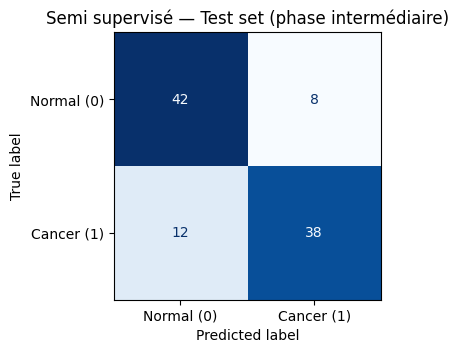

In [27]:
loader_temp = DataLoader(
    MRIset(test_df, transform=TRANSFORMS), batch_size=10, shuffle=False, pin_memory=True
)

all_preds_temp = []
all_labels_temp = []

model.eval()
with torch.no_grad():
    for imgs, labels in loader_temp:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds_temp.extend(preds.cpu().numpy())
        all_labels_temp.extend(labels.cpu().numpy())

# Check label alignment: if GMM labels are flipped vs true labels,
# the model predicts everything backwards → ARI negative, accuracy < 0.5
alignment_check = pd.DataFrame({"true": all_labels_temp, "pred": all_preds_temp})
print("Distribution des prédictions vs vrais labels (test set 70 images) :")
print(alignment_check.groupby(["true", "pred"]).size().unstack(fill_value=0))
print(f"\n→ Si TP+TN < FP+FN : labels GMM inversés par rapport aux vrais labels")

results_temp = evaluate(
    all_labels_temp,
    all_preds_temp,
    title="Semi supervisé — Test set (phase intermédiaire)",
)

## Phase 1 Evaluation sur le set de validation

In [28]:
torch.save(model.state_dict(), "model_phase1.pth")

In [29]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for imgs, labels in loader_val:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

────────────────────────────────────────
  CNN — Val set (phase 1)
────────────────────────────────────────
  Accuracy  : 0.8000
  Precision : 0.8000
  Recall    : 0.8000
  F1-score  : 0.8000
  F2-score  : 0.8000
  ARI       : 0.3371
────────────────────────────────────────



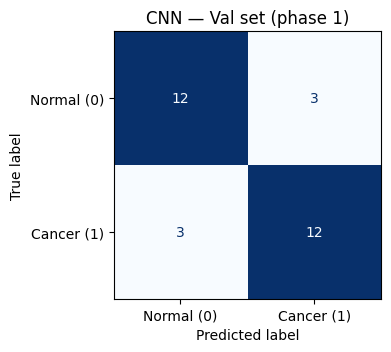

In [30]:
results_phase1_val = evaluate(all_labels, all_preds, title="CNN — Val set (phase 1)")

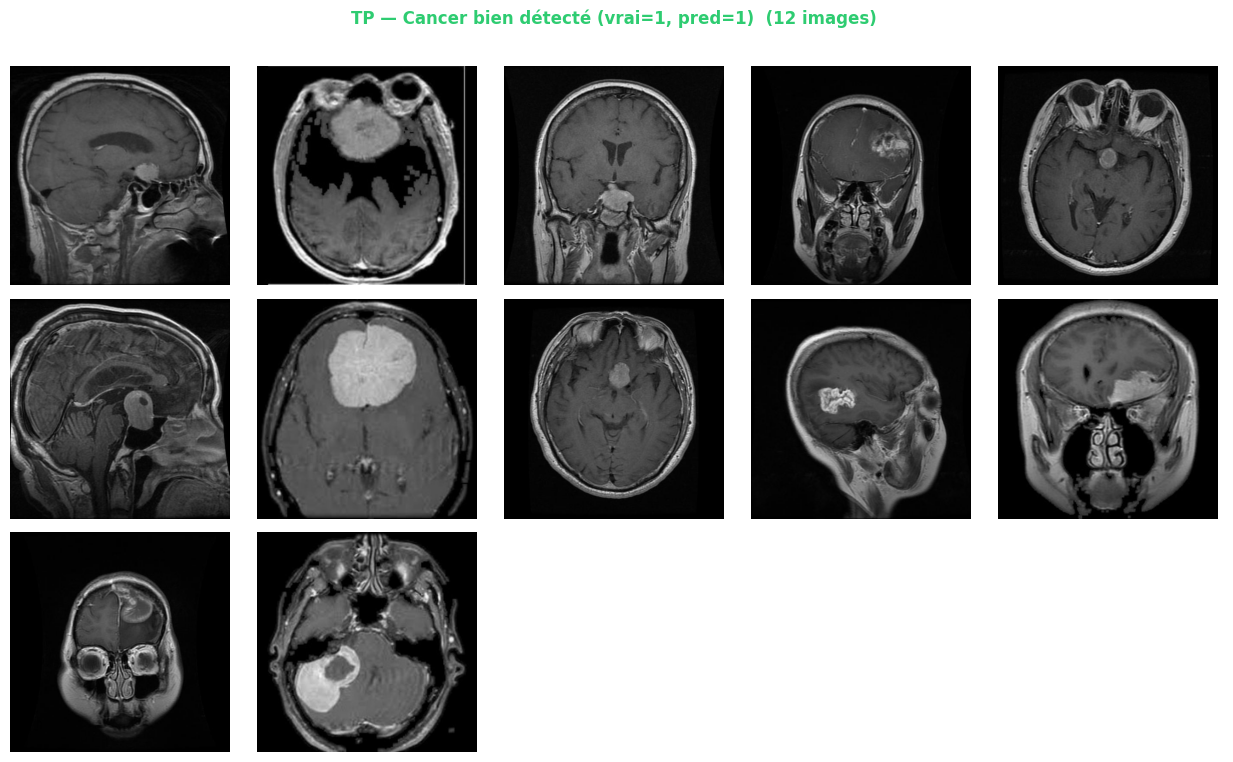

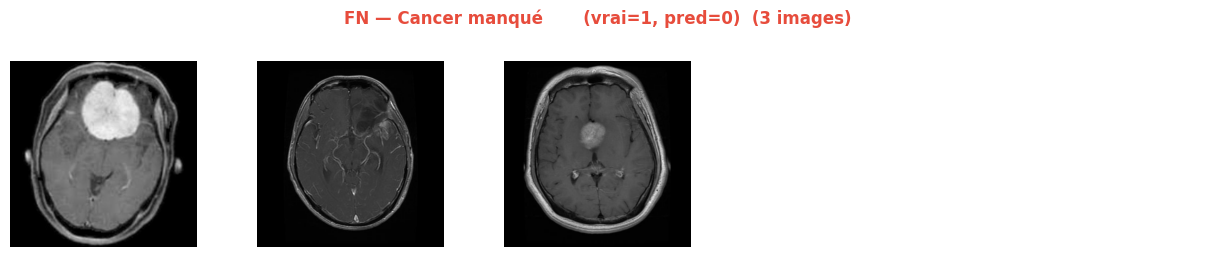

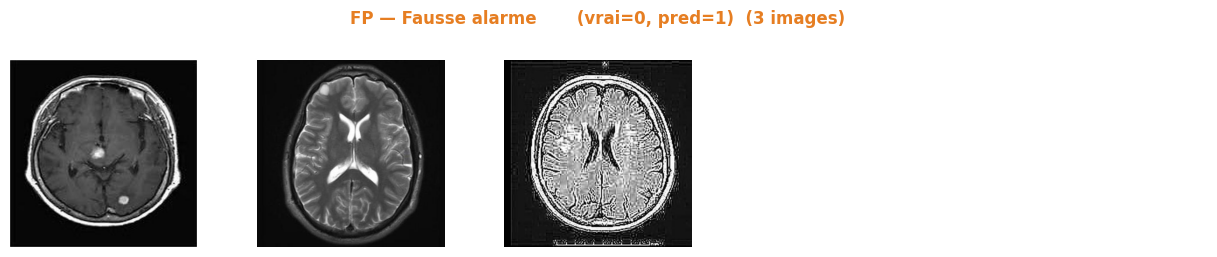

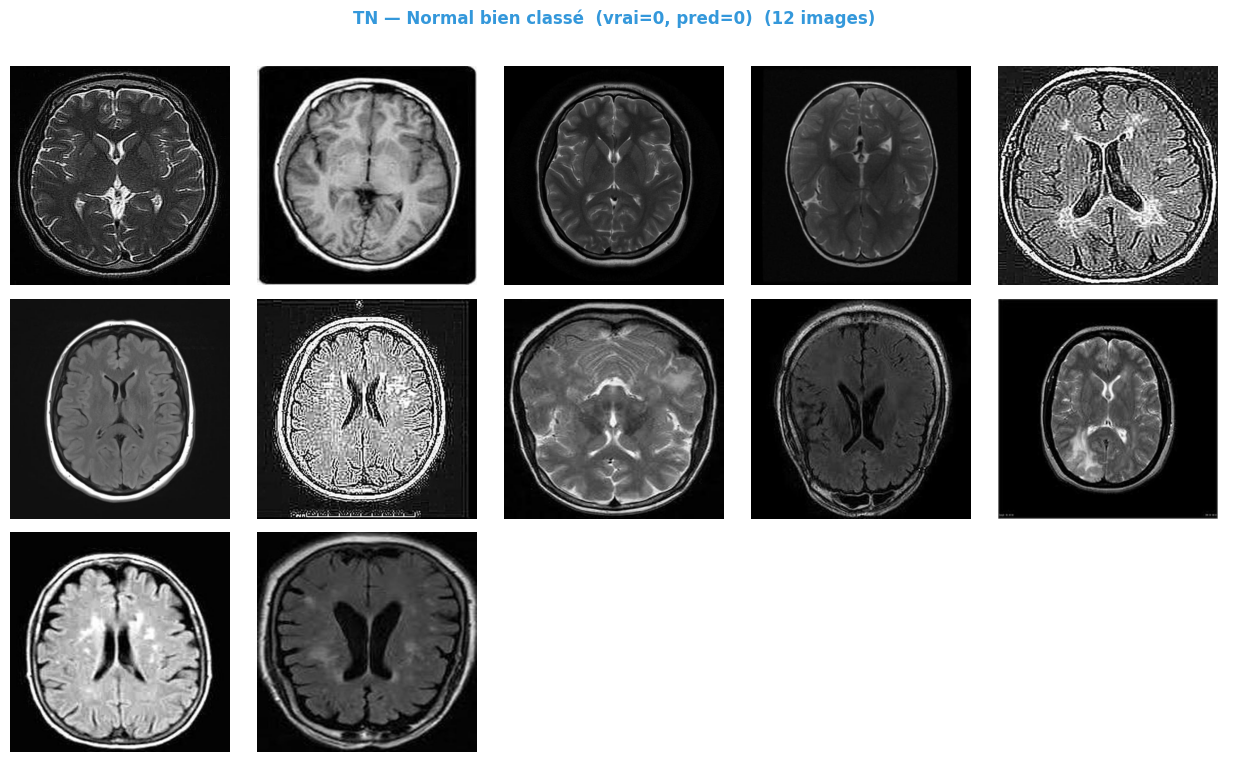

In [31]:
def plot_confusion_images(df, y_true, y_pred, n_cols=5):
    """
    Display val images grouped by confusion matrix quadrant.
    df      : DataFrame with image_path column (same order as y_true/y_pred)
    y_true  : list/array of true labels
    y_pred  : list/array of predicted labels
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    quadrants = {
        "TP — Cancer bien détecté (vrai=1, pred=1)": np.where(
            (y_true == 1) & (y_pred == 1)
        )[0],
        "FN — Cancer manqué       (vrai=1, pred=0)": np.where(
            (y_true == 1) & (y_pred == 0)
        )[0],
        "FP — Fausse alarme       (vrai=0, pred=1)": np.where(
            (y_true == 0) & (y_pred == 1)
        )[0],
        "TN — Normal bien classé  (vrai=0, pred=0)": np.where(
            (y_true == 0) & (y_pred == 0)
        )[0],
    }
    colors = {"TP": "#2ecc71", "FN": "#e74c3c", "FP": "#e67e22", "TN": "#3498db"}
    color_list = [colors["TP"], colors["FN"], colors["FP"], colors["TN"]]

    for (title, indices), color in zip(quadrants.items(), color_list):
        if len(indices) == 0:
            print(f"  {title} : aucune image\n")
            continue

        n_rows = (len(indices) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
        fig.suptitle(
            f"{title}  ({len(indices)} images)",
            fontsize=12,
            color=color,
            fontweight="bold",
            y=1.01,
        )
        axes = np.array(axes).flatten()

        for i, idx in enumerate(indices):
            img = Image.open(df.iloc[idx]["image_path"]).convert("RGB")
            axes[i].imshow(img)
            axes[i].axis("off")
            for spine in axes[i].spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)

        for j in range(len(indices), len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        plt.show()


plot_confusion_images(
    labeled_val_df.reset_index(drop=True),
    all_labels,
    all_preds,
)

## Grad-CAM — Pourquoi le modèle se trompe ?

Grad-CAM — Phase 1 — FN (cancers manqués) :


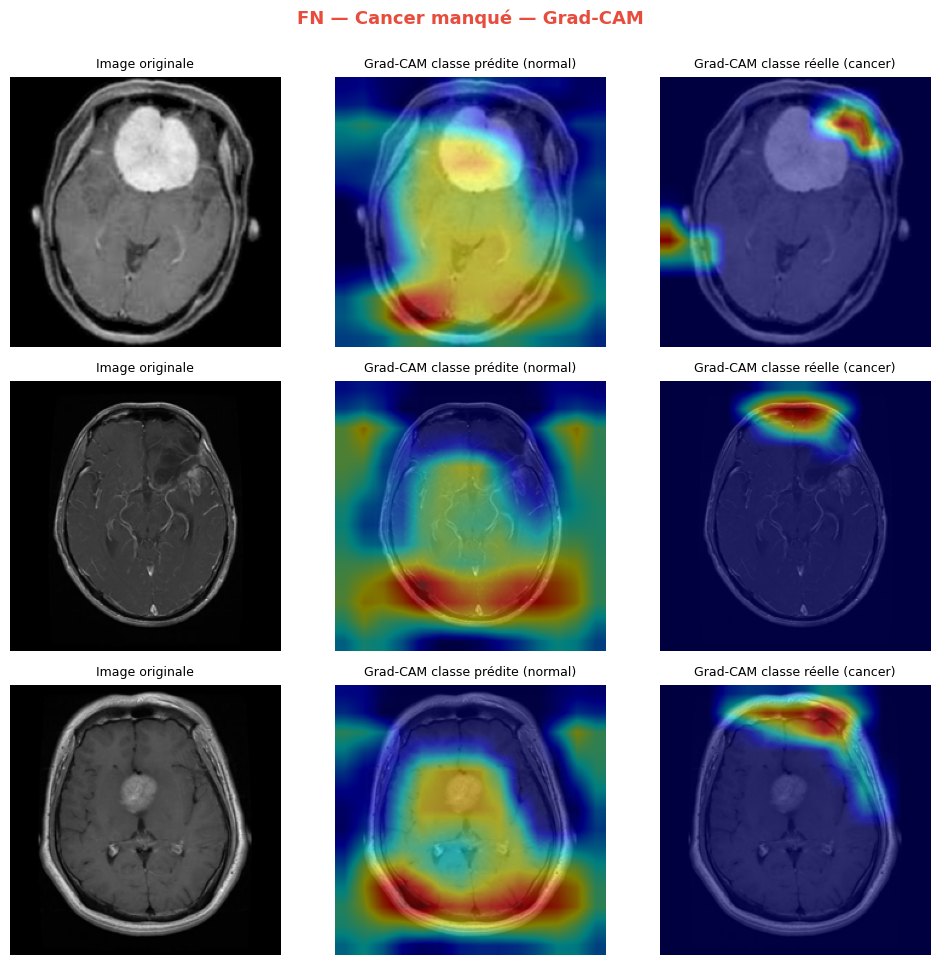

Grad-CAM — Phase 1 — FP (fausses alarmes) :


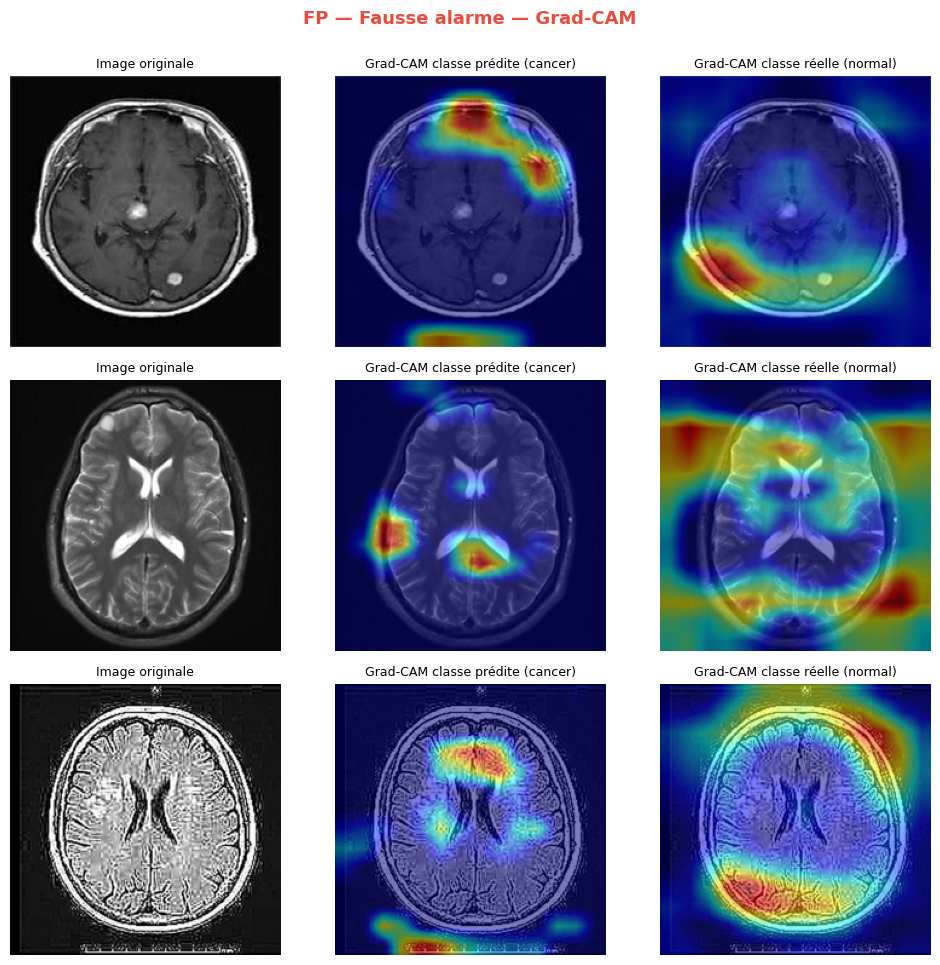

In [32]:
run_gradcam_analysis(
    model,
    labeled_val_df.reset_index(drop=True),
    all_labels,
    all_preds,
    phase="Phase 1",
)

# Phase 2 Fine tuning sur labels forts

Phase 2 — fine-tuning (backbone gelé)
Paramètres entraînés : 131,842 / 1,701,410 (7.7%)

Epoch 01/10 — loss: 0.6856
Epoch 02/10 — loss: 0.5223
Epoch 03/10 — loss: 0.5357
Epoch 04/10 — loss: 0.4109
Epoch 05/10 — loss: 0.5680
Epoch 06/10 — loss: 0.5419
Epoch 07/10 — loss: 0.4593
Epoch 08/10 — loss: 0.4296
Epoch 09/10 — loss: 0.4674
Epoch 10/10 — loss: 0.4529

Modèle sauvegardé → model_phase2.pth
────────────────────────────────────────
  Phase 2 — Fine-tuning labels forts
────────────────────────────────────────
  Accuracy  : 0.9000
  Precision : 0.8750
  Recall    : 0.9333
  F1-score  : 0.9032
  F2-score  : 0.9211
  ARI       : 0.6272
────────────────────────────────────────



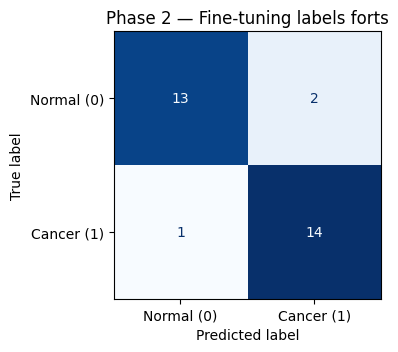

Grad-CAM — Phase 2 — FN (cancers manqués) :


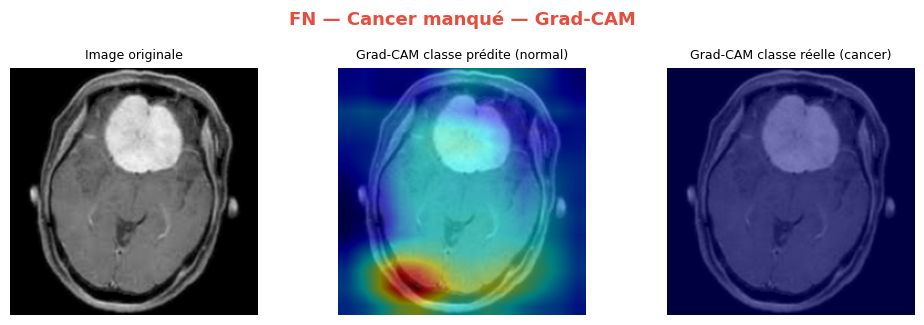

Grad-CAM — Phase 2 — FP (fausses alarmes) :


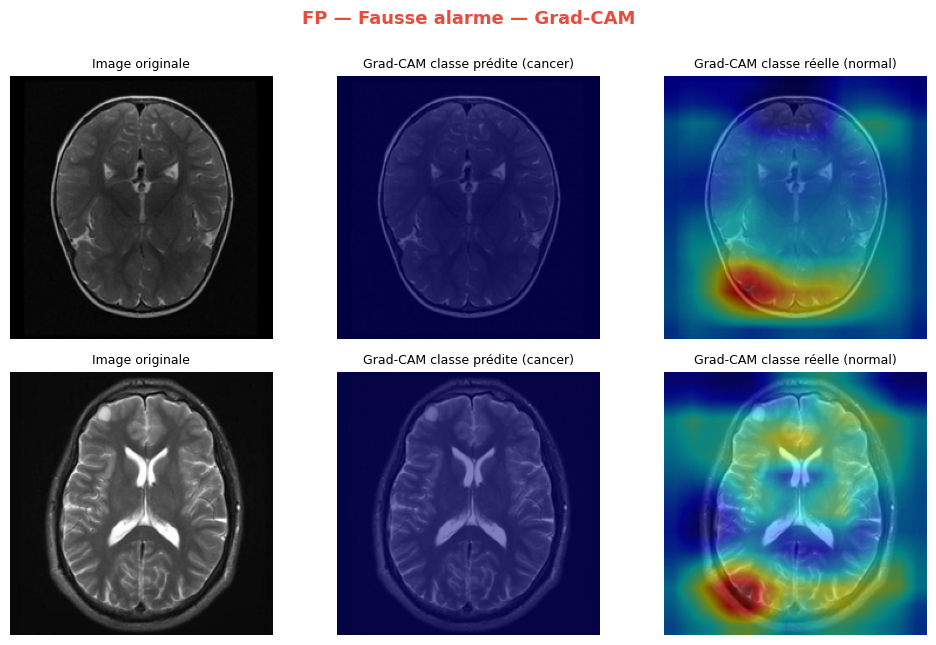

In [33]:
# ── Phase 2 : Fine-tuning on strong labels (70 images) ──────────────────────
# Strategy : freeze backbone (model.features), train classifier head only.
# This preserves the representations learned in phase 1 on pseudo-labels
# and only recalibrates the final decision layer using the 70 strong labels.

# Reload phase 1 weights — ensures phase 2 starts from the semi-supervised checkpoint
model.load_state_dict(torch.load("model_phase1.pth", map_location=DEVICE))

# Freeze the convolutional backbone entirely
for param in model.features.parameters():
    param.requires_grad = False

# Only the classifier head will be updated
optimizer_p2 = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

TRAIN_TRANSFORMS = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

loader_strong = DataLoader(
    MRIset(labeled_test_df, transform=TRAIN_TRANSFORMS),
    batch_size=10,
    shuffle=True,
    pin_memory=True,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Phase 2 — fine-tuning (backbone gelé)")
print(f"Paramètres entraînés : {trainable:,} / {total:,} ({100*trainable/total:.1f}%)\n")

for epoch in range(10):
    model.train()
    epoch_loss = 0.0
    for imgs, labels in loader_strong:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()
        optimizer_p2.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_p2.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/10 — loss: {epoch_loss / len(loader_strong):.4f}")

torch.save(model.state_dict(), "model_phase2.pth")
print("\nModèle sauvegardé → model_phase2.pth")

# Unfreeze backbone for GradCAM (requires gradients through all layers)
for param in model.features.parameters():
    param.requires_grad = True

# ── Inference on val set ──────────────────────────────────────────────────────
all_preds_p2 = []
all_labels_p2 = []

model.eval()
with torch.no_grad():
    for imgs, labels in loader_val:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds_p2.extend(preds.cpu().numpy())
        all_labels_p2.extend(labels.numpy())

results_p2 = evaluate(
    all_labels_p2, all_preds_p2, title="Phase 2 — Fine-tuning labels forts"
)

run_gradcam_analysis(
    model,
    labeled_val_df.reset_index(drop=True),
    all_labels_p2,
    all_preds_p2,
    phase="Phase 2",
)

# Phase 3 Entrainement completement supervisé

Supervisé pur — entraînement sur 70 images

Epoch 01/8 — loss: 0.6575
Epoch 02/8 — loss: 0.5699
Epoch 03/8 — loss: 0.5789
Epoch 04/8 — loss: 0.4755
Epoch 05/8 — loss: 0.4149
Epoch 06/8 — loss: 0.4488
Epoch 07/8 — loss: 0.4905
Epoch 08/8 — loss: 0.3854

Modèle sauvegardé → model_supervised.pth
────────────────────────────────────────
  Supervisé pur — 70 labels forts
────────────────────────────────────────
  Accuracy  : 0.8333
  Precision : 0.8125
  Recall    : 0.8667
  F1-score  : 0.8387
  F2-score  : 0.8553
  ARI       : 0.4247
────────────────────────────────────────



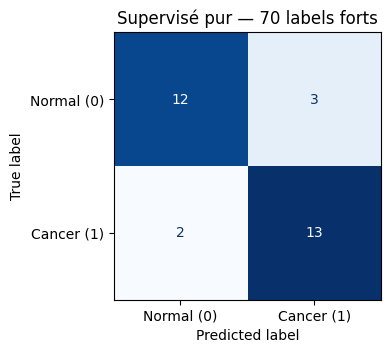

In [34]:
# ── Fully supervised baseline — fresh MyCNN, 70 strong labels only ───────────

# Re-initialize from scratch — no influence from phase 1 or 2
model_sup = MyCNN().to(DEVICE)

optimizer_sup = torch.optim.Adam(model_sup.parameters(), lr=1e-3)
criterion_sup = nn.CrossEntropyLoss()

print("Supervisé pur — entraînement sur 70 images\n")
for epoch in range(8):
    model_sup.train()
    epoch_loss = 0.0
    for imgs, labels in loader_strong:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE).long()
        optimizer_sup.zero_grad()
        outputs = model_sup(imgs)
        loss = criterion_sup(outputs, labels)
        loss.backward()
        optimizer_sup.step()
        epoch_loss += loss.item()
    print(f"Epoch {epoch+1:02d}/8 — loss: {epoch_loss / len(loader_strong):.4f}")

torch.save(model_sup.state_dict(), "model_supervised.pth")
print("\nModèle sauvegardé → model_supervised.pth")

# ── Inference on val set ──────────────────────────────────────────────────────
all_preds_sup = []
all_labels_sup = []

model_sup.eval()
with torch.no_grad():
    for imgs, labels in loader_val:
        imgs = imgs.to(DEVICE)
        outputs = model_sup(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds_sup.extend(preds.cpu().numpy())
        all_labels_sup.extend(labels.numpy())

results_sup = evaluate(
    all_labels_sup, all_preds_sup, title="Supervisé pur — 70 labels forts"
)

Grad-CAM — Phase 3 — Supervisé pur — FN (cancers manqués) :


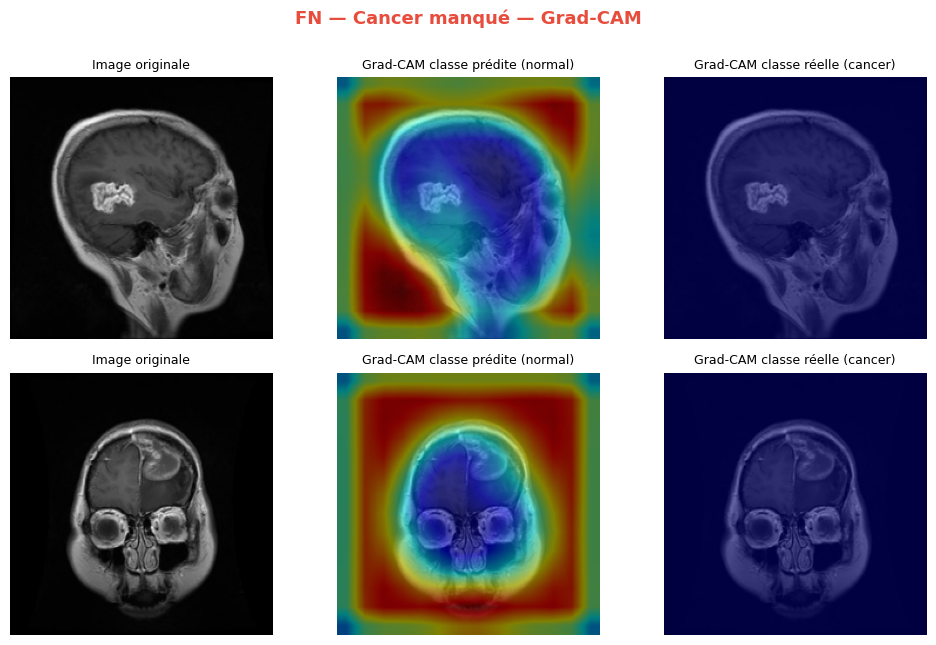

Grad-CAM — Phase 3 — Supervisé pur — FP (fausses alarmes) :


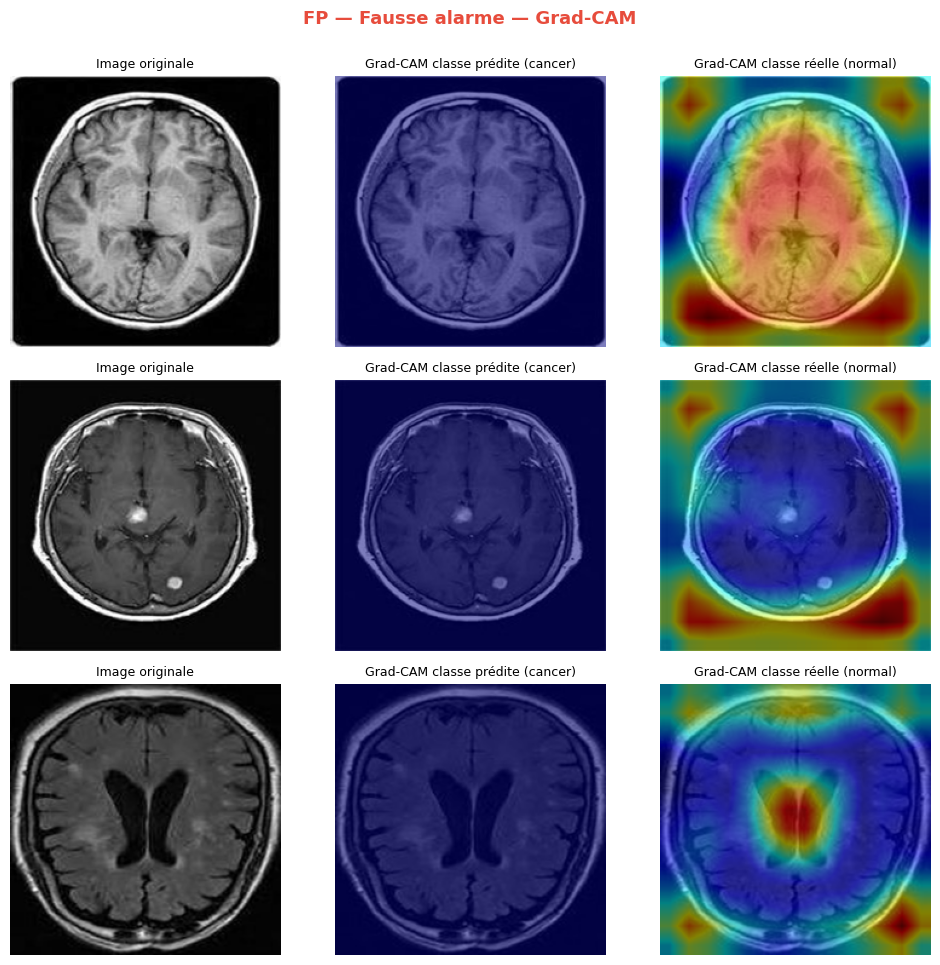

In [35]:
run_gradcam_analysis(
    model_sup,
    labeled_val_df.reset_index(drop=True),
    all_labels_sup,
    all_preds_sup,
    phase="Phase 3 — Supervisé pur",
)

# Phase 0 GMM — Baseline val set

────────────────────────────────────────
  GMM — Val set (baseline)
────────────────────────────────────────
  Accuracy  : 0.8000
  Precision : 0.9091
  Recall    : 0.6667
  F1-score  : 0.7692
  F2-score  : 0.7042
  ARI       : 0.3388
────────────────────────────────────────



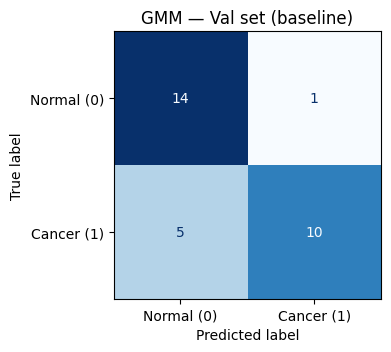

In [36]:
# ── GMM baseline — val set (30 images) ───────────────────────────────────────
# proba_cancer / proba_normal already stored in labeled_val_df from true_labels_test.csv
gmm_val_preds = (labeled_val_df["proba_cancer"] >= 0.5).astype(int).tolist()
gmm_val_labels = labeled_val_df["label"].tolist()

results_gmm = evaluate(gmm_val_labels, gmm_val_preds, title="GMM — Val set (baseline)")

# Tableau recapitulatif :

In [37]:
# ── Recap comparatif ──────────────────────────────────────────────────────────
print("\n" + "═" * 50)
print("  COMPARAISON DES APPROCHES (val set, 30 images)")
print("═" * 50)
rows = [
    ("GMM — clustering pseudo-labels (baseline)",     results_gmm),
    ("Phase 1 — pseudo-labels CNN (1406)",            results_phase1_val),
    ("Phase 2 — fine-tuning classifieur (1406+70)",   results_p2),
    ("Phase 3 — Supervisé pur (70)",                  results_sup),
]
print(f"{'Modèle':<48} {'Acc':>6} {'Rec':>6} {'F2':>6} {'ARI':>6}")
print("─" * 70)
for name, r in rows:
    print(
        f"{name:<48} {r['accuracy']:>6.3f} {r['recall']:>6.3f} {r['f2']:>6.3f} {r['ari']:>6.3f}"
    )


══════════════════════════════════════════════════
  COMPARAISON DES APPROCHES (val set, 30 images)
══════════════════════════════════════════════════
Modèle                                              Acc    Rec     F2    ARI
──────────────────────────────────────────────────────────────────────
GMM — clustering pseudo-labels (baseline)         0.800  0.667  0.704  0.339
Phase 1 — pseudo-labels CNN (1406)                0.800  0.800  0.800  0.337
Phase 2 — fine-tuning classifieur (1406+70)       0.900  0.933  0.921  0.627
Phase 3 — Supervisé pur (70)                      0.833  0.867  0.855  0.425
